In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from html2image import Html2Image
import os

hti = Html2Image()
# Create directory for PNGs
os.makedirs('../reports/png_charts', exist_ok=True)


## 1. NAV Trend Analysis

In [61]:
# Task 1: NAV trend analysis
print('Task 1: NAV trend analysis')
df_nav = pd.read_csv('../data/02_nav_history.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav_filtered = df_nav[(df_nav['date'].dt.year >= 2022) & (df_nav['date'].dt.year <= 2026)]

fig = px.line(df_nav_filtered, x='date', y='nav', color='amfi_code', 
              title='Daily NAV for All Schemes (2022-2026)')
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.2, 
              annotation_text="2023 Bull Run", annotation_position="top left")
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.2, 
              annotation_text="2024 Market Corrections", annotation_position="top left")

hti.screenshot(html_str=fig.to_html(), save_as='nav_trend_analysis_temp.png', size=(1200, 800))
import shutil
if os.path.exists('nav_trend_analysis_temp.png'):
    shutil.move('nav_trend_analysis_temp.png', '../reports/png_charts/nav_trend_analysis.png')
fig.show()



# Task 1b: NAV Volatility (Box Plot)
fig2 = px.box(df_nav_filtered, x='amfi_code', y='nav', title='NAV Volatility Distribution by Scheme')
fig2.show()
hti.screenshot(html_str=fig2.to_html(), save_as='nav_volatility_box.png', size=(1200, 800))

# Task 1c: Final NAV Comparison (Bar Chart)
df_final = df_nav_filtered.sort_values('date').groupby('amfi_code').tail(1)
fig3 = px.bar(df_final.assign(amfi_code=df_final['amfi_code'].astype(str)), x='amfi_code', y='nav', title='Final NAV Comparison Across Schemes (End of Period)', color='nav')
fig3.show()
hti.screenshot(html_str=fig3.to_html(), save_as='nav_final_bar.png', size=(1200, 800))

import shutil
if os.path.exists('nav_volatility_box.png'): shutil.move('nav_volatility_box.png', '../reports/png_charts/nav_volatility_box.png')
if os.path.exists('nav_final_bar.png'): shutil.move('nav_final_bar.png', '../reports/png_charts/nav_final_bar.png')

Task 1: NAV trend analysis


## 2. AUM Growth Bar Chart

Task 2: AUM growth bar chart


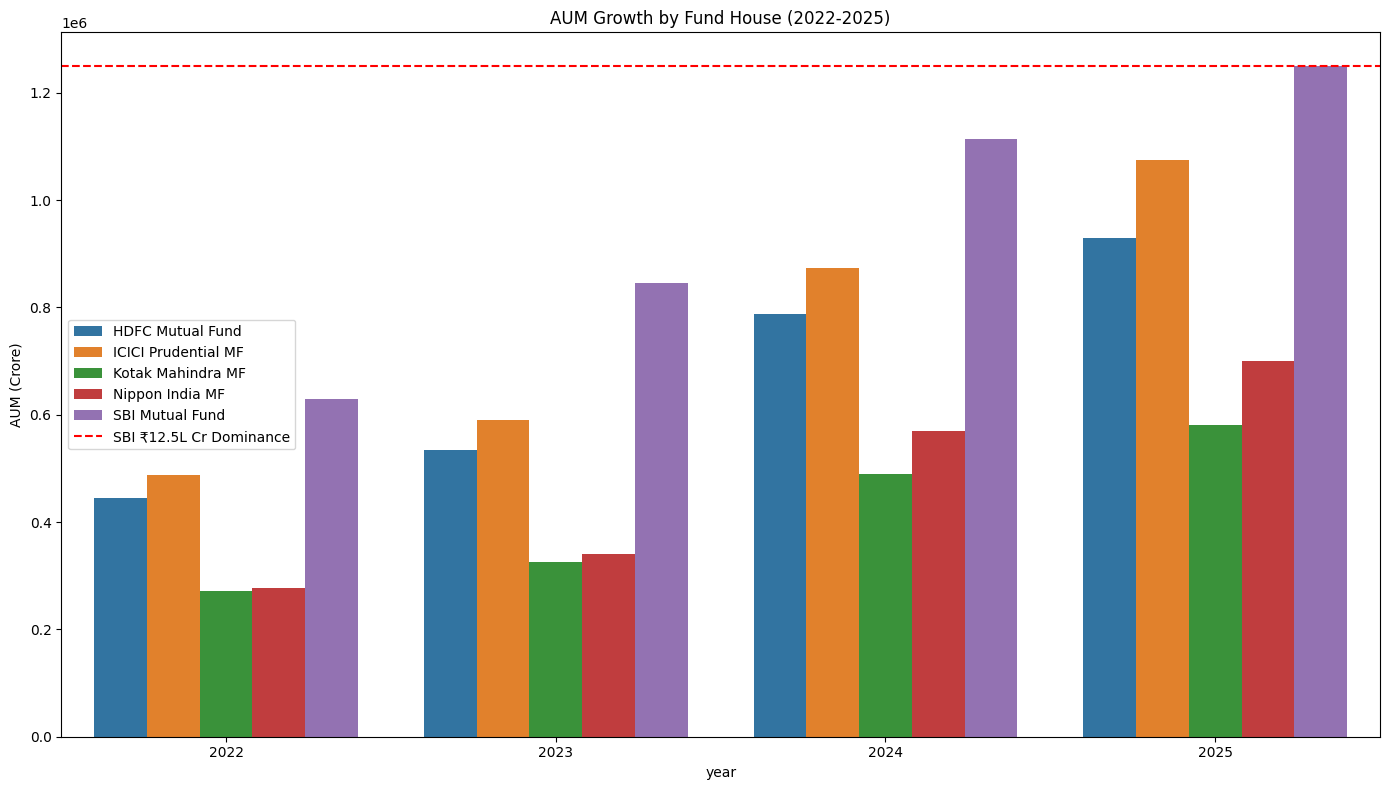

In [3]:
# Task 2: AUM growth bar chart
print('Task 2: AUM growth bar chart')
df_aum = pd.read_csv('../data/03_aum_by_fund_house.csv')
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum['year'] = df_aum['date'].dt.year
# Use max() to get the peak AUM for the year instead of summing across quarters
top_5_fh = df_aum.groupby('fund_house')['aum_crore'].max().sort_values(ascending=False).head(5).index
df_aum_yearly = df_aum[(df_aum['year'] >= 2022) & (df_aum['year'] <= 2025) & (df_aum['fund_house'].isin(top_5_fh))].groupby(['year', 'fund_house'])['aum_crore'].max().reset_index()

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=df_aum_yearly, x='year', y='aum_crore', hue='fund_house')
plt.title('AUM Growth by Fund House (2022-2025)')
plt.ylabel('AUM (Crore)')
sbi_aum_12_5 = 1250000 
plt.axhline(y=sbi_aum_12_5, color='r', linestyle='--', label='SBI ₹12.5L Cr Dominance')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/png_charts/aum_growth_bar.png')
plt.show()


## 3. SIP Inflow Time-Series

In [4]:
# Task 3: SIP inflow time-series
print('Task 3: SIP inflow time-series')
df_sip = pd.read_csv('../data/04_monthly_sip_inflows.csv')
df_sip['month_year'] = pd.to_datetime(df_sip['month'])
df_sip = df_sip.sort_values('month_year')

fig = px.line(df_sip, x='month_year', y='sip_inflow_crore', title='Monthly SIP Trend (Jan 2022 - Dec 2025)')
fig.add_annotation(x="2025-12-01", y=31002,
            text="₹31,002 Cr All-Time High",
            showarrow=True,
            arrowhead=1)

hti.screenshot(html_str=fig.to_html(), save_as='sip_inflow_trend_temp.png', size=(1200, 800))
if os.path.exists('sip_inflow_trend_temp.png'):
    shutil.move('sip_inflow_trend_temp.png', '../reports/png_charts/sip_inflow_trend.png')
fig.show()



# Task 3b: Yearly Total SIP Inflows (Bar Chart)
df_sip['year'] = pd.to_datetime(df_sip['month_year']).dt.year
df_sip_yearly = df_sip.groupby('year')['sip_inflow_crore'].sum().reset_index()
fig4 = px.bar(df_sip_yearly, x='year', y='sip_inflow_crore', title='Total Yearly SIP Inflows', text_auto=True)
fig4.show()
hti.screenshot(html_str=fig4.to_html(), save_as='sip_yearly_bar.png', size=(1200, 800))

import shutil
if os.path.exists('sip_yearly_bar.png'): shutil.move('sip_yearly_bar.png', '../reports/png_charts/sip_yearly_bar.png')

Task 3: SIP inflow time-series


## 4. Category Inflow Heatmap

Task 4: Category inflow heatmap


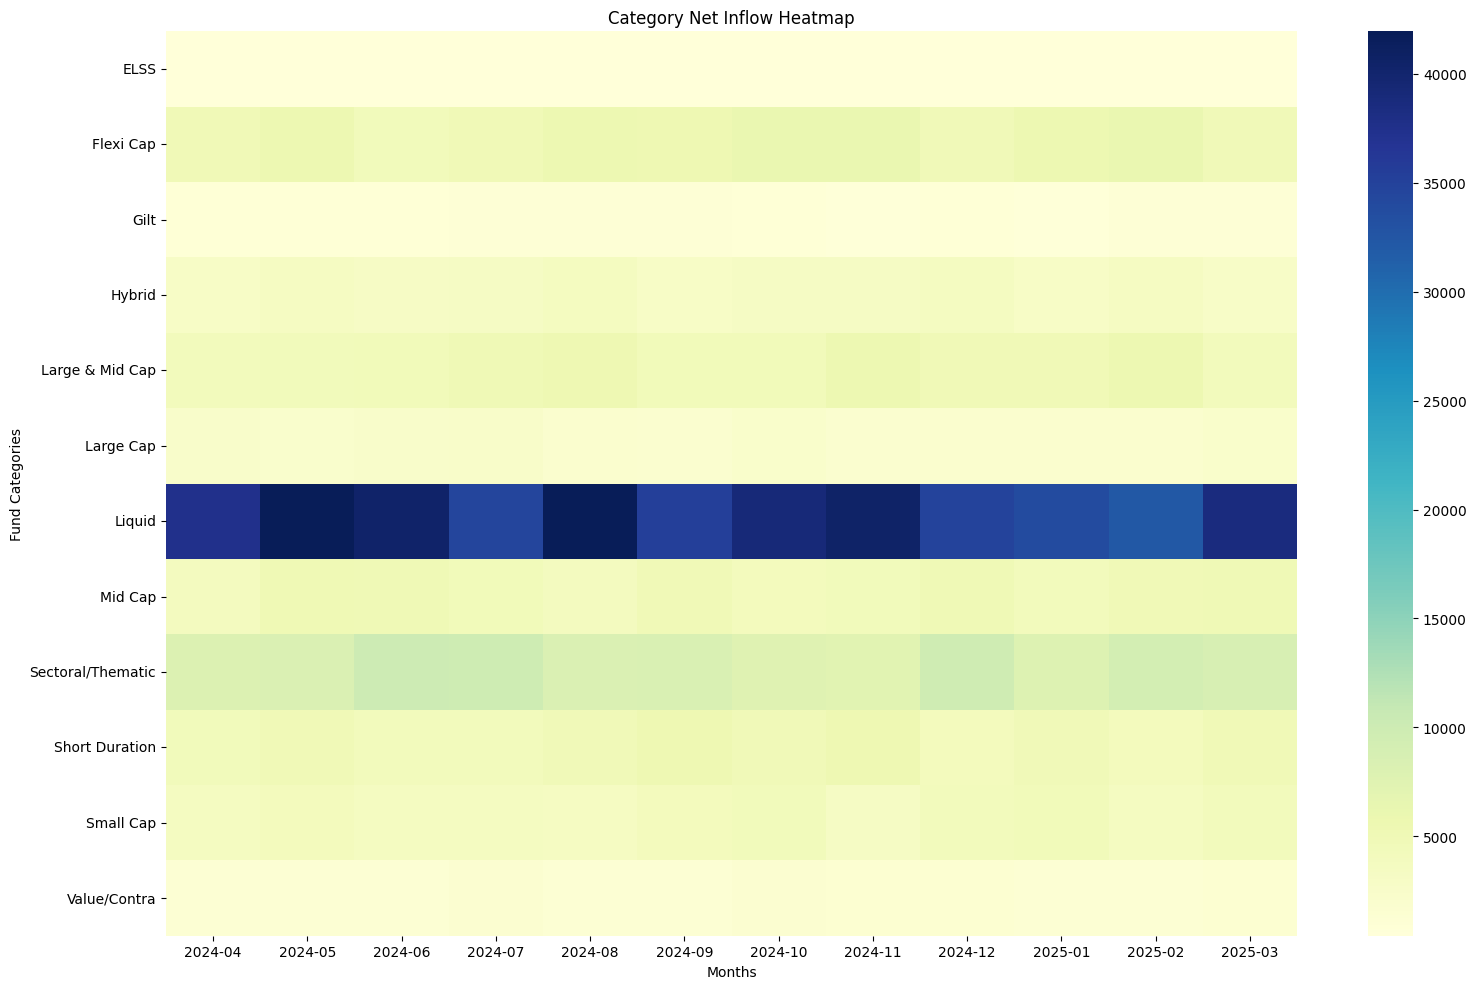

In [5]:
# Task 4: Category inflow heatmap
print('Task 4: Category inflow heatmap')
df_cat = pd.read_csv('../data/05_category_inflows.csv')
df_cat['month_year'] = df_cat['month']
pivot_cat = df_cat.pivot_table(index='category', columns='month_year', values='net_inflow_crore', aggfunc='sum')

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_cat, cmap='YlGnBu', annot=False)
plt.title('Category Net Inflow Heatmap')
plt.xlabel('Months')
plt.ylabel('Fund Categories')
plt.tight_layout()
plt.savefig('../reports/png_charts/category_inflow_heatmap.png')
plt.show()


## 5. Investor Demographics

Task 5: Investor demographics


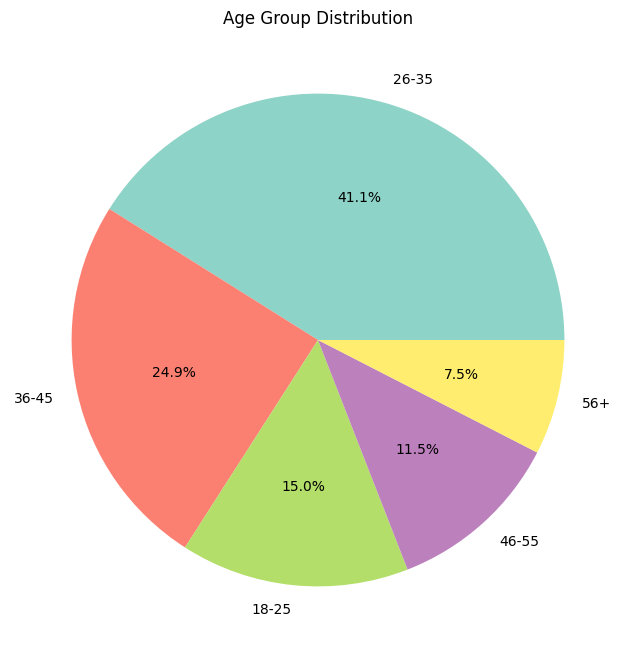

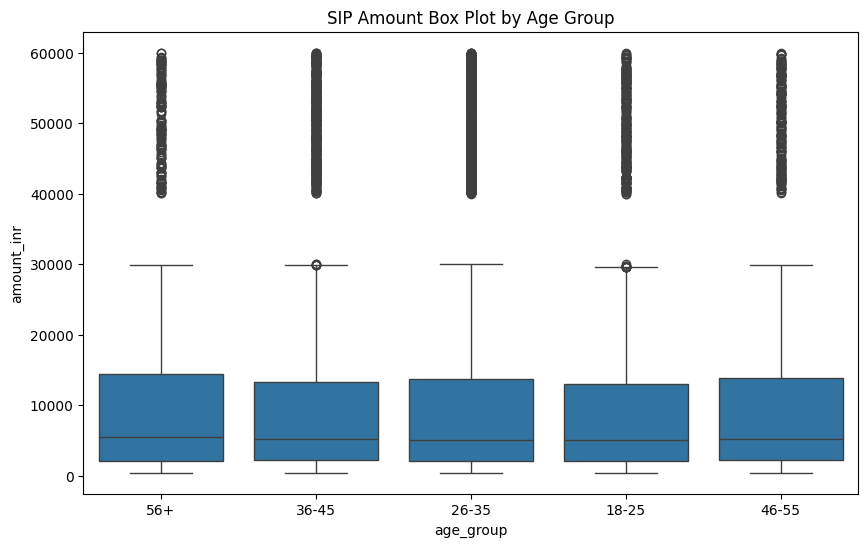

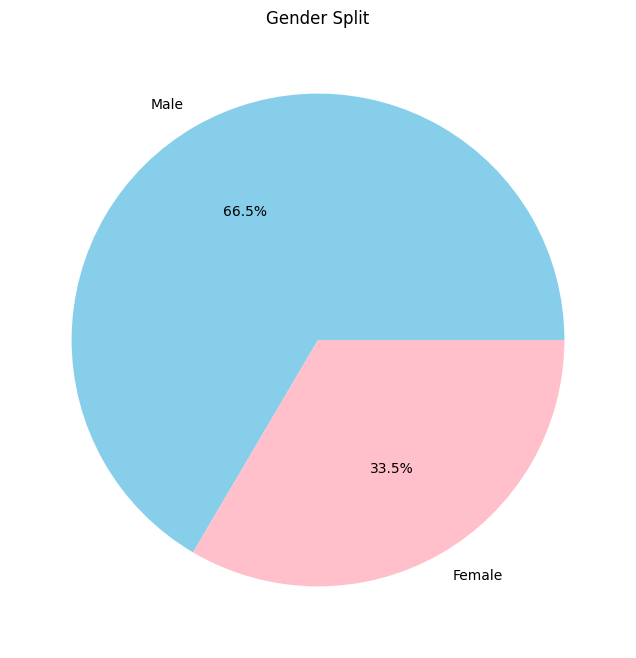

In [6]:
# Task 5: Investor demographics
print('Task 5: Investor demographics')
df_inv = pd.read_csv('../data/08_investor_transactions.csv')

plt.figure(figsize=(8, 8))
df_inv['age_group'].value_counts().plot.pie(autopct='%1.1f%%', colormap='Set3')
plt.title('Age Group Distribution')
plt.ylabel('')
plt.savefig('../reports/png_charts/age_group_pie.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_inv[df_inv['transaction_type'] == 'SIP'], x='age_group', y='amount_inr')
plt.title('SIP Amount Box Plot by Age Group')
plt.savefig('../reports/png_charts/sip_amount_boxplot.png')
plt.show()

plt.figure(figsize=(8, 8))
df_inv['gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'pink', 'lightgray'])
plt.title('Gender Split')
plt.ylabel('')
plt.savefig('../reports/png_charts/gender_split_pie.png')
plt.show()


## 6. Geographic Distribution

Task 6: Geographic distribution


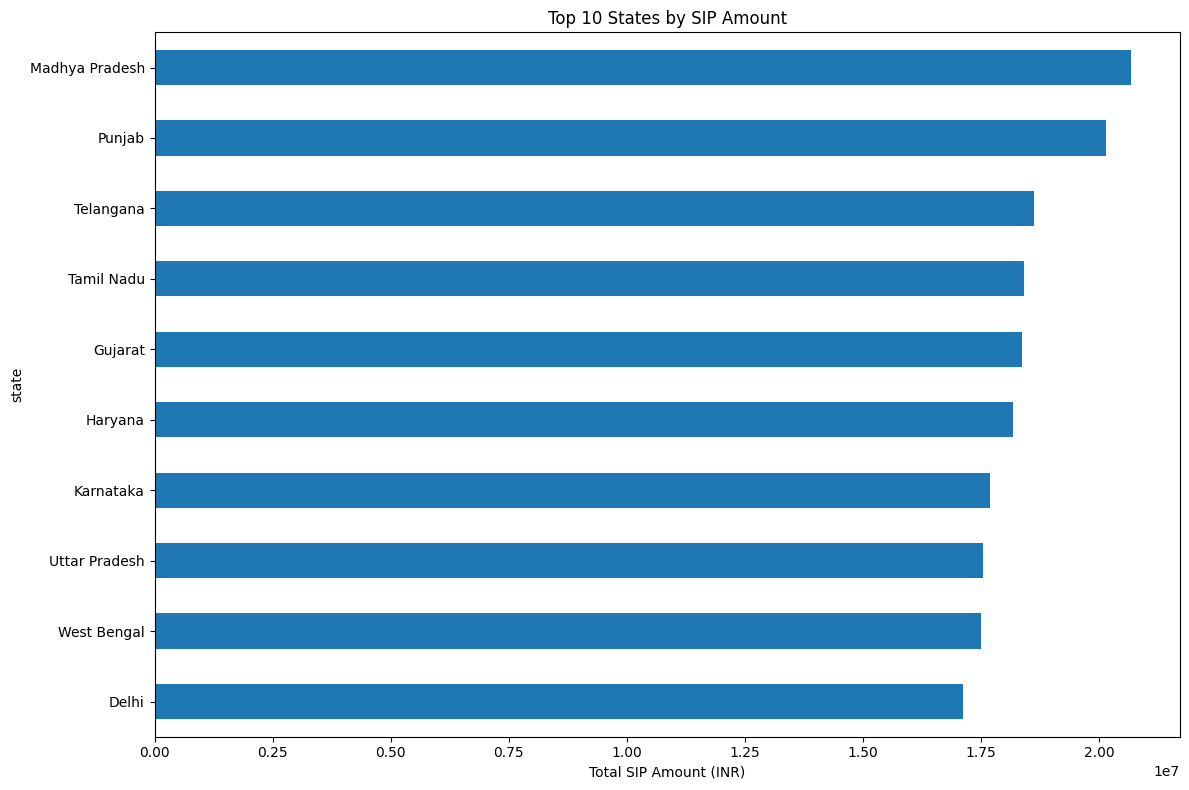

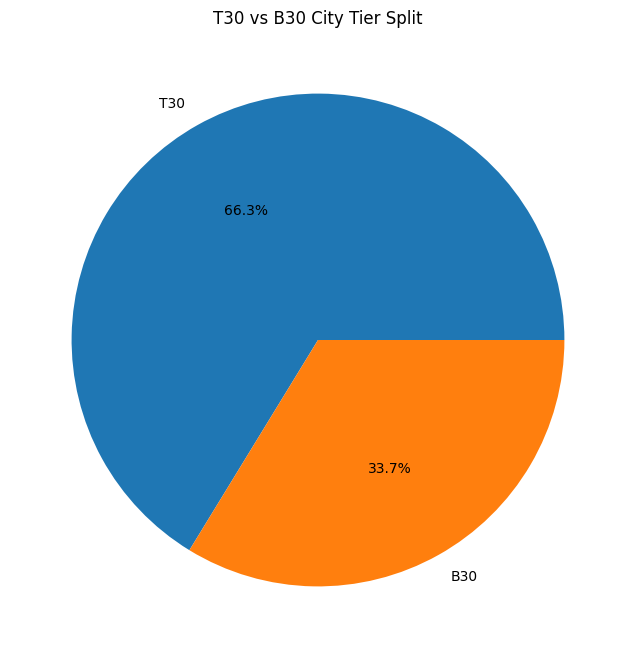

In [7]:
# Task 6: Geographic distribution
print('Task 6: Geographic distribution')
df_sip_only = df_inv[df_inv['transaction_type'] == 'SIP']
state_sip = df_sip_only.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
state_sip.sort_values().plot(kind='barh')
plt.title('Top 10 States by SIP Amount')
plt.xlabel('Total SIP Amount (INR)')
plt.tight_layout()
plt.savefig('../reports/png_charts/sip_by_state_bar.png')
plt.show()

plt.figure(figsize=(8, 8))
df_inv['city_tier'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('T30 vs B30 City Tier Split')
plt.ylabel('')
plt.savefig('../reports/png_charts/city_tier_pie.png')
plt.show()


## 7. Folio Count Growth

In [8]:
# Task 7: Folio count growth
print('Task 7: Folio count growth')
df_folio = pd.read_csv('../data/06_industry_folio_count.csv')
df_folio['month_year'] = pd.to_datetime(df_folio['month'])
df_folio = df_folio.sort_values('month_year')

fig = px.line(df_folio, x='month_year', y='total_folios_crore', title='Folio Count Growth (Jan 2022 - Dec 2025)')
fig.add_annotation(x="2022-01-01", y=13.26, text="13.26 Cr (Jan 2022)", showarrow=True)
fig.add_annotation(x="2025-12-01", y=26.12, text="26.12 Cr (Dec 2025)", showarrow=True)
hti.screenshot(html_str=fig.to_html(), save_as='folio_count_growth_temp.png', size=(1200, 800))
if os.path.exists('folio_count_growth_temp.png'):
    shutil.move('folio_count_growth_temp.png', '../reports/png_charts/folio_count_growth.png')
fig.show()



Task 7: Folio count growth


## 8. NAV Return Correlation Matrix

Task 8: NAV return correlation matrix


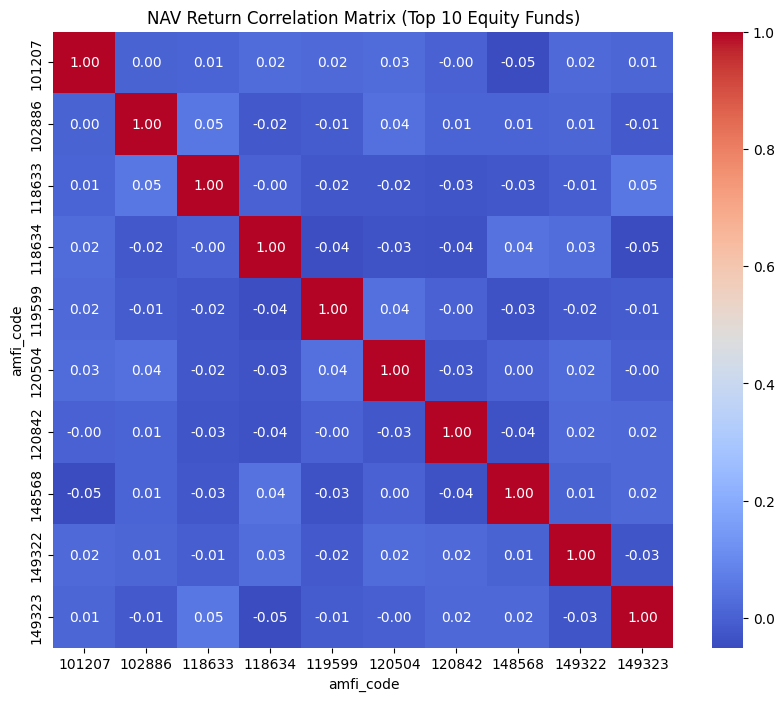

In [9]:
# Task 8: NAV return correlation matrix
print('Task 8: NAV return correlation matrix')
df_nav2 = pd.read_csv('../data/02_nav_history.csv')
df_nav2['date'] = pd.to_datetime(df_nav2['date'])

df_perf = pd.read_csv('../data/07_scheme_performance.csv')
df_master = pd.read_csv('../data/01_fund_master.csv')

# Get Equity funds
equity_amfis = df_master[df_master['category'] == 'Equity']['amfi_code']
# Filter performance data for Equity funds and get Top 10 by AUM
top_equity_funds = df_perf[df_perf['amfi_code'].isin(equity_amfis)].sort_values('aum_crore', ascending=False).head(10)
top_equity_amfi = top_equity_funds['amfi_code'].tolist()

df_nav_subset = df_nav2[df_nav2['amfi_code'].isin(top_equity_amfi)]
pivot_nav = df_nav_subset.pivot(index='date', columns='amfi_code', values='nav')
daily_returns = pivot_nav.pct_change()
corr_matrix = daily_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('NAV Return Correlation Matrix (Top 10 Equity Funds)')
plt.savefig('../reports/png_charts/nav_correlation_heatmap.png')
plt.show()


## 9. Sector Allocation Donut

Task 9: Sector allocation donut


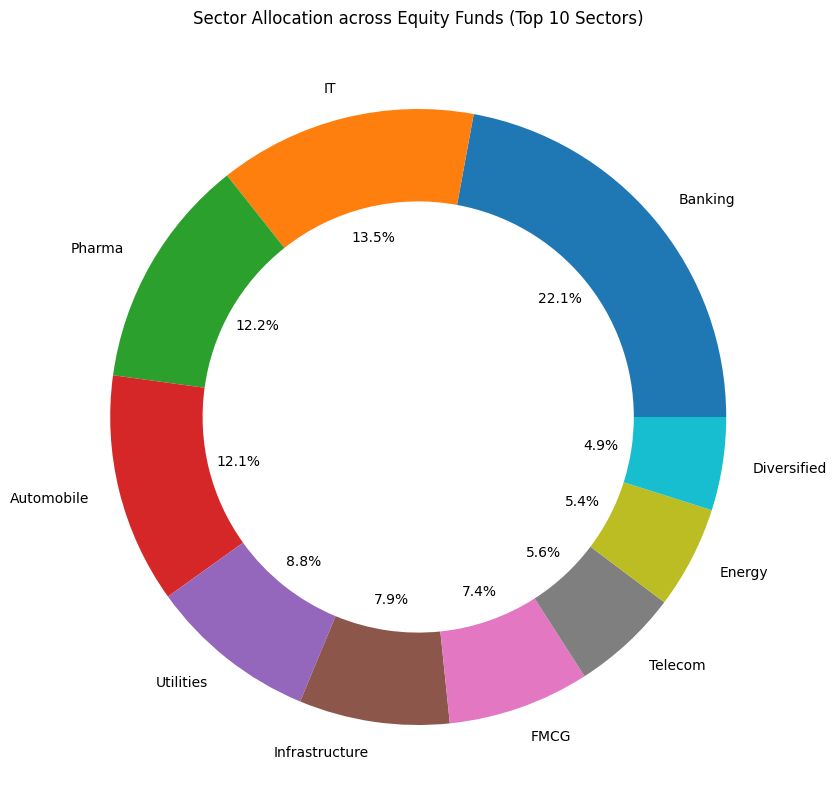

In [10]:
# Task 9: Sector allocation donut
print('Task 9: Sector allocation donut')
df_holdings = pd.read_csv('../data/09_portfolio_holdings.csv')
df_master = pd.read_csv('../data/01_fund_master.csv')
equity_funds = df_master[df_master['category'] == 'Equity']['amfi_code'].tolist()

df_equity_holdings = df_holdings[df_holdings['amfi_code'].isin(equity_funds)]
# Top 10 sectors across equity funds
sector_weights = df_equity_holdings.groupby('sector')['market_value_cr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 10))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', wedgeprops={'width': 0.3})
plt.title('Sector Allocation across Equity Funds (Top 10 Sectors)')
plt.savefig('../reports/png_charts/sector_allocation_donut.png')
plt.show()


## 10. Key EDA Findings
- The 2023 bull run saw a consistent upward trend across most mutual fund schemes. (Reference: NAV Trend Analysis)
- Market corrections in 2024 introduced high volatility in daily NAVs. (Reference: NAV Trend Analysis)
- SBI Mutual Fund showed dominance by approaching ₹12.5L Cr AUM. (Reference: AUM Growth Bar Chart)
- SIP inflows reached an all-time high of ₹31,002 Cr in December 2025. (Reference: SIP Inflow Time-Series)
- Equity categories generally saw the highest net inflows over the observed period. (Reference: Category Inflow Heatmap)
- A significant portion of investors fall within the younger age demographic. (Reference: Age Group Distribution)
- SIP investment amounts show variation across age groups, with middle-aged brackets generally investing more. (Reference: SIP Amount Box Plot)
- T30 cities contribute to a substantial portion of the investor base compared to B30 cities. (Reference: City Tier Pie Chart)
- Industry folio counts nearly doubled from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025. (Reference: Folio Count Growth)
- High correlation exists among top equity funds, indicating similar market movements. (Reference: NAV Return Correlation Matrix)

In [11]:
# Task 10: 10 key EDA findings
print('Finished executing notebook')


Finished executing notebook
